# STARmapPlus_AD

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import matplotlib.pyplot as plt
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]

import pysodb
sodb = pysodb.SODB()
adata_dict = sodb.load_dataset('Zeng2023Integrative')


load experimentonths-control-replicate_1] in dataset[Zeng2023Integrative]
load experimentonths-control-replicate_2] in dataset[Zeng2023Integrative]
load experimentonths-disease-replicate_1] in dataset[Zeng2023Integrative]
load experimentonths-disease-replicate_2] in dataset[Zeng2023Integrative]
load experimentonths-control-replicate_1] in dataset[Zeng2023Integrative]
load experimentonths-control-replicate_2] in dataset[Zeng2023Integrative]
load experimentonths-disease-replicate_1] in dataset[Zeng2023Integrative]
load experimentonths-disease-replicate_2] in dataset[Zeng2023Integrative]


In [3]:
# specify slice_id and ground truth
adata_list = []
for si in adata_dict.keys():
    adata = adata_dict[si]
    adata.obs['slice_id'] = si
    adata_list.append(adata)
adata_raw = adata_list[0].concatenate(adata_list[1:])
adata_raw.obs['slice_id'] = adata_raw.obs['slice_id'].astype('category')
adata_raw.obs['ct'] = adata_raw.obs['ct_sub'].astype('category')





In [4]:
adata_raw

AnnData object with n_obs × n_vars = 72165 × 2766
    obs: 'ct_top', 'ct_sub', 'sample', 'leiden', 'slice_id', 'batch', 'ct'
    var: 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'highly_variable-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'highly_variable-3', 'means-3', 'dispersions-3', 'dispersions_norm-3', 'highly_variable-4', 'means-4', 'dispersions-4', 'dispersions_norm-4', 'highly_variable-5', 'means-5', 'dispersions-5', 'dispersions_norm-5', 'highly_variable-6', 'means-6', 'dispersions-6', 'dispersions_norm-6', 'highly_variable-7', 'means-7', 'dispersions-7', 'dispersions_norm-7'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [5]:
batch_obs = 'slice_id'


In [6]:
# input parameters of MENDER
scale = 6




adata = adata_raw.copy()


# main body of MENDER
msm = MENDER.MENDER(
    adata,
    batch_obs = batch_obs, 
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct'
)


# set the MENDER parameters


msm.prepare()

msm.estimate_radius()

estimated radius: 105.38500842150178
13months-control-replicate_1:estimated radius:105.38500842150178
estimated radius: 106.6770828247567
13months-control-replicate_2:estimated radius:106.6770828247567
estimated radius: 102.80077820717118
13months-disease-replicate_1:estimated radius:102.80077820717118
estimated radius: 104.20892451322024
13months-disease-replicate_2:estimated radius:104.20892451322024
estimated radius: 106.75673116497356
8months-control-replicate_1:estimated radius:106.75673116497356
estimated radius: 108.85311203635843
8months-control-replicate_2:estimated radius:108.85311203635843
estimated radius: 109.82258334900115
8months-disease-replicate_1:estimated radius:109.82258334900115
estimated radius: 111.46299834474219
8months-disease-replicate_2:estimated radius:111.46299834474219


In [7]:
# this radius is set to 150 (not 15) is because according to the output of msm.estimate_radius(), the unit of spatial is 0.1 um
time_st = time.time()
radius = 150


msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for the analysis).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=radius, 

)
# construct the context representation
msm.run_representation_mp(
    200
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(-0.5)
time_cost = time.time()-time_st





default number of process is 200
total batch: 8, running batch 13months-control-replicate_1
total batch: 8, running batch 13months-control-replicate_2
total batch: 8, running batch 13months-disease-replicate_1
total batch: 8, running batch 13months-disease-replicate_2
total batch: 8, running batch 8months-control-replicate_1
total batch: 8, running batch 8months-control-replicate_2
total batch: 8, running batch 8months-disease-replicate_1
total batch: 8, running batch 8months-disease-replicate_2
scale 0, median #cells per radius (r=150): 3.0
scale 0, median #cells per radius (r=150): 3.0
scale 0, median #cells per radius (r=150): 2.0
scale 0, median #cells per radius (r=150): 2.0
scale 0, median #cells per radius (r=150): 2.0
scale 0, median #cells per radius (r=150): 3.0
scale 0, median #cells per radius (r=150): 3.0
scale 0, median #cells per radius (r=150): 3.0
scale 1, median #cells per radius (r=150): 5.0
scale 1, median #cells per radius (r=150): 5.0
scale 1, median #cells per ra

In [8]:
print(f'cost {time_cost} s for {adata_raw.shape[0]} cells')

cost 69.43808317184448 s for 72165 cells


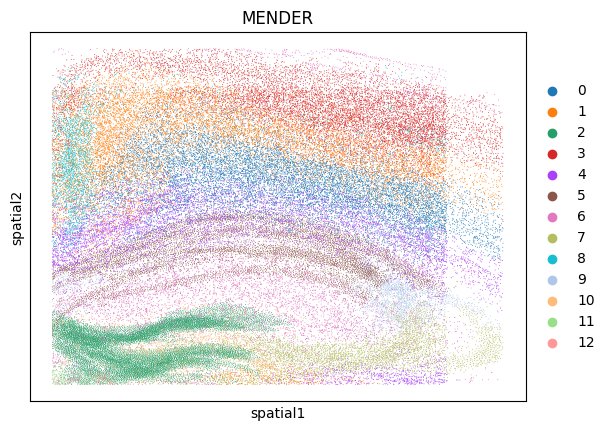

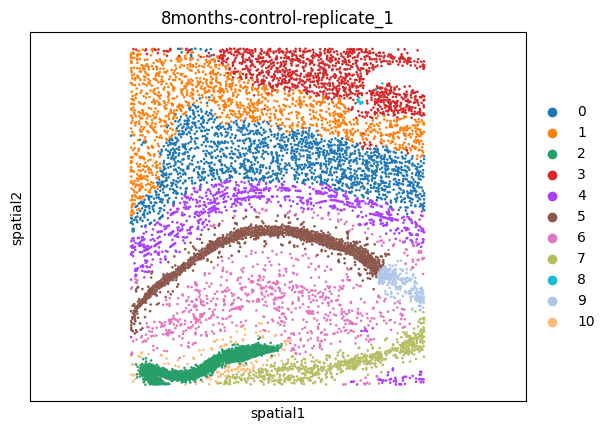

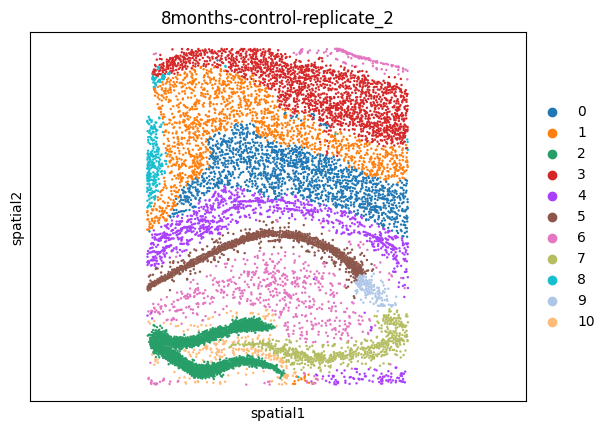

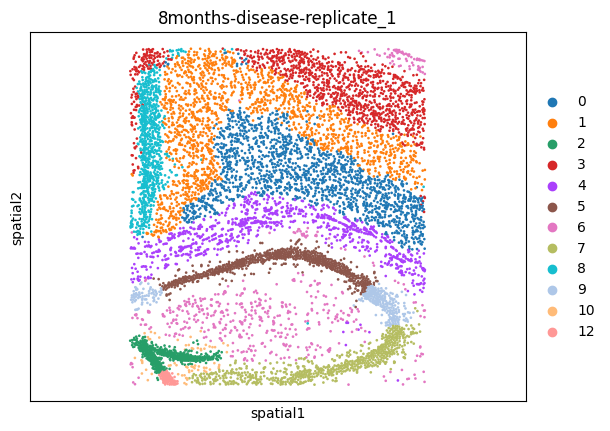

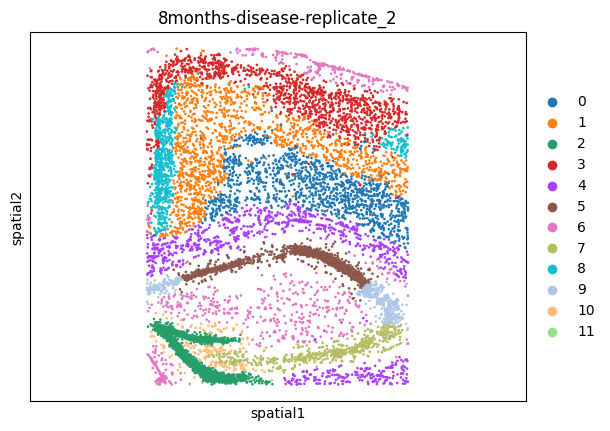

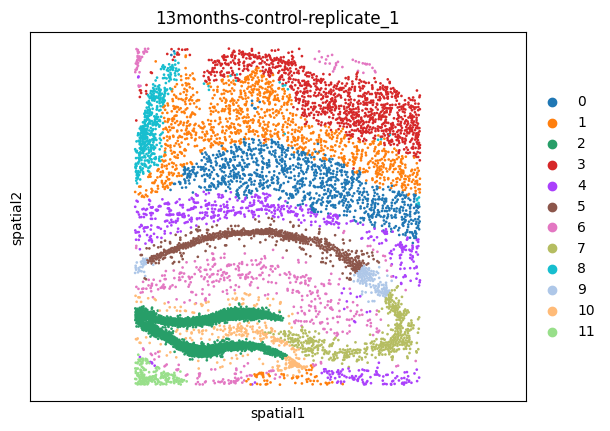

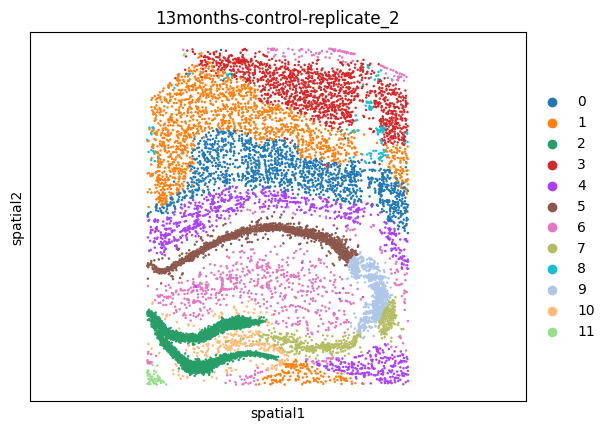

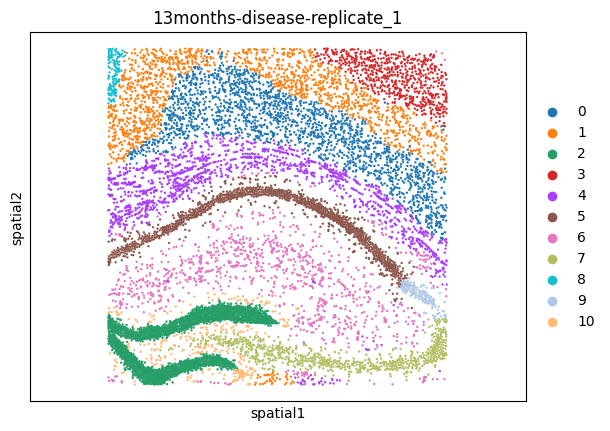

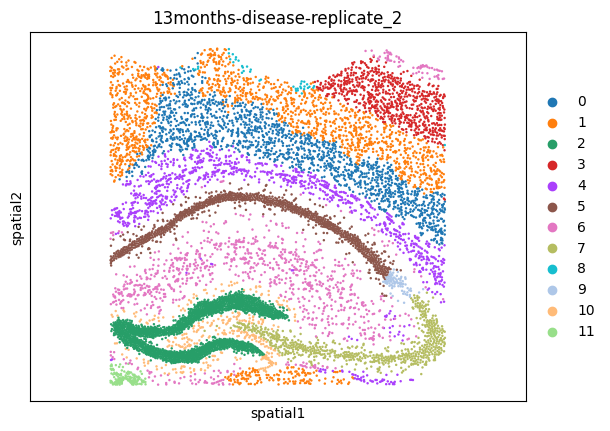

In [9]:
msm.output_cluster_all()

In [10]:
msm.adata_MENDER.write_h5ad('dump/STARmapPlus_AD.h5ad')

